In [19]:
from qiskit import __version__

print(__version__)

2.5.2


In [20]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, Operator
from numpy import sqrt

In [28]:
zero = Statevector.from_label("0")
one = Statevector.from_label("1")
psi = zero ^ zero
display(psi.draw("latex"))

<IPython.core.display.Latex object>

In [17]:
H = Operator.from_label("H")
Z = Operator.from_label("Z")
CX = Operator([[1, 0, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0], [0, 1, 0, 0]])

In [18]:
display(psi.evolve(CX @ (Z ^ H)).draw("latex"))

<IPython.core.display.Latex object>

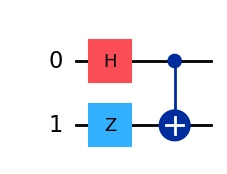

In [23]:
qubit0 = QuantumRegister(1, "0")
qubit1 = QuantumRegister(1, "1")

protocol = QuantumCircuit(qubit0, qubit1)

protocol.h(qubit0)
protocol.z(qubit1)
protocol.cx(qubit0, qubit1)

display(protocol.draw(output="mpl"))

In [26]:
display(psi.evolve(protocol).draw("latex"))

<IPython.core.display.Latex object>

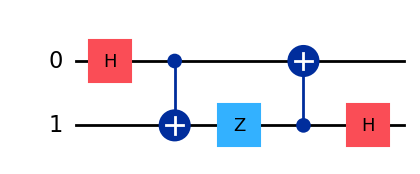

In [27]:
protocol2 = QuantumCircuit(qubit0, qubit1)

protocol2.h(qubit0)
protocol2.cx(qubit0, qubit1)
protocol2.z(qubit1)
protocol2.cx(qubit1, qubit0)
protocol2.h(qubit1)

display(protocol2.draw(output="mpl"))

In [31]:
psi2 = one ^ zero

display(psi2.evolve(protocol2).draw("latex"))

<IPython.core.display.Latex object>

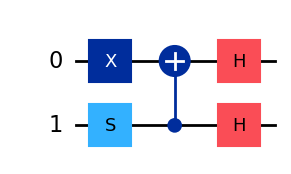

In [38]:
protocol3 = QuantumCircuit(qubit0, qubit1)

protocol3.x(qubit0)
protocol3.s(qubit1)
protocol3.cx(qubit1, qubit0)
protocol3.h(qubit0)
protocol3.h(qubit1)

display(protocol3.draw(output="mpl"))

In [39]:
display(Operator.from_circuit(protocol3).draw("latex"))

<IPython.core.display.Latex object>

In [50]:
psi0 = 1/sqrt(3) * Statevector.from_label("0") \
        + sqrt(2/3) * Statevector.from_label("1")

Pi0 = psi0.to_operator()

In [68]:
Id = Operator.from_label("I")
res = (Id ^ Pi0) @ (sqrt(2)/3 * (zero ^ zero) - 1/3 * (zero ^ one) \
                    + sqrt(2)/3 * (one ^ zero) + 2/3 * (one ^ one))

In [70]:
res.inner(res)

np.complex128(0.6666666666666669+0j)

In [71]:
res

Statevector([5.55111512e-17+0.j, 5.55111512e-17+0.j, 4.71404521e-01+0.j,
             6.66666667e-01+0.j],
            dims=(2, 2))
